# Playing with RoBERTa

## Setup

In [1]:
import torch
from transformers import RobertaModel, RobertaTokenizer, RobertaForMaskedLM
from transformers import DataCollatorForLanguageModeling
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
from tqdm import tqdm


In [2]:
print("=" * 80)
print("Loading RoBERTa Base Model")
print("=" * 80)

model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaForMaskedLM.from_pretrained(model_name)

Loading RoBERTa Base Model


In [ ]:
# small sample - use streaming to avoid downloading entire dataset
lang_pair = "de-en"
dataset = load_dataset("wmt19", lang_pair, split="train", streaming=True) 

# Get just the first example
example = next(iter(dataset))
print(f"Language pair: {lang_pair}")
print(f"Example translation keys: {example['translation'].keys() if 'translation' in example else 'N/A'}")
print(f"Example translation: `{example['translation']['en']}` translates to `{example['translation']['de']}`")
print()

## Playing with special tokens

In [ ]:
translation = example['translation']
english_text = translation['en']
german_text = translation['de']

english_tokens = tokenizer.tokenize(english_text)
german_tokens = tokenizer.tokenize(german_text)

print("Tokenization (without special tokens):")
print(f"English tokens ({len(english_tokens)}): {english_tokens}")
print(f"German tokens ({len(german_tokens)}): {german_tokens}")
print()

In [ ]:
english_ids = tokenizer.convert_tokens_to_ids(english_tokens)
german_ids = tokenizer.convert_tokens_to_ids(german_tokens)

print(f"English tokens ({len(english_ids)}): {english_ids}")
print(f"German tokens ({len(german_ids)}): {german_ids}")

In [11]:
# [CLS] English ... [SEP] [CLS] German ... [SEP]
sequence_ids = [
    tokenizer.cls_token_id,        # First CLS (before English)
    *english_ids,                  # English tokens
    tokenizer.sep_token_id,        # SEP token
    tokenizer.cls_token_id,        # Second CLS (before German)
    *german_ids,                   # German tokens
    tokenizer.sep_token_id         # Final SEP
]

print(f"Sequence length: {len(sequence_ids)}")
print(f"Sequence structure:")
print(f"  [CLS] + {len(english_ids)} English tokens + [CLS] + [SEP] + {len(german_ids)} German tokens + [SEP]")
print(f"Sequence: {sequence_ids}")
print()

Sequence length: 24
Sequence structure:
  [CLS] + 5 English tokens + [CLS] + [SEP] + 15 German tokens + [SEP]
Sequence: [0, 20028, 21236, 9, 5, 1852, 2, 0, 771, 2550, 254, 1180, 42441, 895, 1794, 1935, 208, 4494, 1545, 29, 1741, 118, 4636, 2]



In [12]:
# Decode to verify the structure
decoded_sequence = tokenizer.decode(sequence_ids, skip_special_tokens=False)
print(f"Decoded sequence:")
print(f"  {decoded_sequence}")
print()

Decoded sequence:
  <s>Resumption of the session</s><s>Wiederaufnahme der Sitzungsperiode</s>



In [13]:
# Show the token IDs breakdown
print("Token IDs breakdown:")
tokens_in_sequence = tokenizer.convert_ids_to_tokens(sequence_ids)
for i in range(len(sequence_ids)):
    print(f"  Position {i:3d}: ID {sequence_ids[i]:6d} | Token: {tokens_in_sequence[i]}")
print()

Token IDs breakdown:
  Position   0: ID      0 | Token: <s>
  Position   1: ID  20028 | Token: Res
  Position   2: ID  21236 | Token: umption
  Position   3: ID      9 | Token: Ġof
  Position   4: ID      5 | Token: Ġthe
  Position   5: ID   1852 | Token: Ġsession
  Position   6: ID      2 | Token: </s>
  Position   7: ID      0 | Token: <s>
  Position   8: ID    771 | Token: W
  Position   9: ID   2550 | Token: ied
  Position  10: ID    254 | Token: er
  Position  11: ID   1180 | Token: au
  Position  12: ID  42441 | Token: fn
  Position  13: ID    895 | Token: ah
  Position  14: ID   1794 | Token: me
  Position  15: ID   1935 | Token: Ġder
  Position  16: ID    208 | Token: ĠS
  Position  17: ID   4494 | Token: itz
  Position  18: ID   1545 | Token: ung
  Position  19: ID     29 | Token: s
  Position  20: ID   1741 | Token: per
  Position  21: ID    118 | Token: i
  Position  22: ID   4636 | Token: ode
  Position  23: ID      2 | Token: </s>



## Playing with masking

In [14]:
input_ids = torch.tensor([sequence_ids])
attention_mask = torch.ones_like(input_ids)

In [15]:
# Find positions
# Structure: [CLS] English ... [SEP] [CLS] German ... [SEP]
first_cls_pos = 0
english_start = 1
english_end = 1 + len(english_ids)
first_sep_pos = english_end  # SEP after English
second_cls_pos = first_sep_pos + 1  # CLS before German
german_start = second_cls_pos + 1  # German tokens start after second CLS
german_end = german_start + len(german_ids)
second_sep_pos = german_end  # Final SEP after German

print("Sequence structure:")
print(f"  Position {first_cls_pos}: First CLS")
print(f"  Positions {english_start}-{english_end-1}: English tokens")
print(f"  Position {first_sep_pos}: First SEP")
print(f"  Position {second_cls_pos}: Second CLS")
print(f"  Positions {german_start}-{german_end-1}: German tokens")
print(f"  Position {second_sep_pos}: Second SEP")
print()

Sequence structure:
  Position 0: First CLS
  Positions 1-5: English tokens
  Position 6: First SEP
  Position 7: Second CLS
  Positions 8-22: German tokens
  Position 23: Second SEP



In [16]:
def create_cross_language_mask(input_ids, english_start, english_end, german_start, german_end, 
                                mask_english=False, mask_german=False):
    """
    Mask everything except the sequence start/end tokens and the language of interest.
    
    Args:
        input_ids: Input sequence [CLS] English ... [SEP] [CLS] German ... [SEP]
        english_start, english_end: English token positions (exclusive end)
        german_start, german_end: German token positions (exclusive end)
        mask_english: If True, mask English tokens (keep German + structure tokens visible)
        mask_german: If True, mask German tokens + its CLS (keep English + structure tokens visible)
    
    Returns:
        masked_input_ids: Input with specified tokens masked
        labels: Labels for loss computation (-100 for non-masked positions)
    """
    masked_input_ids = input_ids.clone()
    labels = torch.full_like(input_ids, -100)  # -100 = ignore in loss
    seq_len = input_ids.shape[1]
    
    # Sequence structure: [CLS] English ... [SEP] [CLS] German ... [SEP]
    first_cls_pos = 0
    first_sep_pos = english_end  # SEP after English
    second_cls_pos = german_start - 1  # CLS before German
    final_sep_pos = german_end  # Final SEP after German
    
    if mask_english:
        # Mask English tokens (keep: first CLS, German section + second CLS, final SEP)
        for pos in range(english_start, min(english_end, seq_len)):
            masked_input_ids[0, pos] = tokenizer.mask_token_id
            labels[0, pos] = input_ids[0, pos].item()
        # Also mask the SEP after English
        if first_sep_pos < seq_len:
            masked_input_ids[0, first_sep_pos] = tokenizer.mask_token_id
            labels[0, first_sep_pos] = input_ids[0, first_sep_pos].item()
    
    if mask_german:
        # Mask German tokens + second CLS (keep: first CLS, English section + first SEP, final SEP)
        if second_cls_pos >= 0:
            masked_input_ids[0, second_cls_pos] = tokenizer.mask_token_id
            labels[0, second_cls_pos] = input_ids[0, second_cls_pos].item()
        for pos in range(german_start, min(german_end, seq_len)):
            masked_input_ids[0, pos] = tokenizer.mask_token_id
            labels[0, pos] = input_ids[0, pos].item()
        # Also mask the final SEP after German
        if final_sep_pos < seq_len:
            masked_input_ids[0, final_sep_pos] = tokenizer.mask_token_id
            labels[0, final_sep_pos] = input_ids[0, final_sep_pos].item()
    
    return masked_input_ids, labels

In [17]:
print("=" * 80)
print("INFERENCE PASS 1: Standard RoBERTa MLM Masking")
print("=" * 80)

# Use DataCollatorForLanguageModeling for standard MLM
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.50
)


INFERENCE PASS 1: Standard RoBERTa MLM Masking


In [18]:

# Apply standard MLM masking
mlm_batch = data_collator([{'input_ids': sequence_ids, 'attention_mask': attention_mask[0].tolist()}])
mlm_input_ids = mlm_batch['input_ids']
mlm_labels = mlm_batch['labels']
mlm_attention_mask = mlm_batch['attention_mask']

print("=" * 80)
print("Visualization: Masked Sequence")
print("=" * 80)

# Decode original and masked sequences
original_decoded = tokenizer.decode(input_ids[0], skip_special_tokens=False)
masked_decoded = tokenizer.decode(mlm_input_ids[0], skip_special_tokens=False)


print("Original sequence:")
print(f"  {original_decoded}")
print()

print("Masked sequence (MLM applied):")
print(f"  {masked_decoded}")
print()


# Show token-by-token comparison
print("Token-by-token comparison:")
tokens_original = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_masked = tokenizer.convert_ids_to_tokens(mlm_input_ids[0])

print("Position | Original Token | Masked Token | Label")
print("-" * 60)
for i in range(len(tokens_original)):
    orig_token = tokens_original[i]
    masked_token = tokens_masked[i]
    label_id = mlm_labels[0, i].item()
    label_token = tokenizer.convert_ids_to_tokens(label_id) if label_id != -100 else "IGNORED"
    
    is_masked = "✓" if orig_token != masked_token else " "
    print(f"  {i:3d}   | {orig_token:14s} | {masked_token:14s} | {label_token:15s} {is_masked}")


# Count masked positions
masked_positions = (mlm_input_ids[0] != input_ids[0]).nonzero(as_tuple=True)[0]
print(f"Masked positions: {masked_positions.tolist()}")
print(f"Number of masked tokens: {len(masked_positions)}")
print()

print("Standard MLM masking applied:")
print(f"  Input IDs shape: {mlm_input_ids.shape}")
print(f"  Labels shape: {mlm_labels.shape}")
print()


Visualization: Masked Sequence
Original sequence:
  <s>Resumption of the session</s><s>Wiederaufnahme der Sitzungsperiode</s>

Masked sequence (MLM applied):
  <s>Res<mask><mask> the<mask></s><s><mask><mask>eraufnahme<mask> S<mask><mask>sper<mask><mask></s>

Token-by-token comparison:
Position | Original Token | Masked Token | Label
------------------------------------------------------------
    0   | <s>            | <s>            | IGNORED          
    1   | Res            | Res            | IGNORED          
    2   | umption        | <mask>         | umption         ✓
    3   | Ġof            | <mask>         | Ġof             ✓
    4   | Ġthe           | Ġthe           | IGNORED          
    5   | Ġsession       | <mask>         | Ġsession        ✓
    6   | </s>           | </s>           | IGNORED          
    7   | <s>            | <s>            | IGNORED          
    8   | W              | <mask>         | W               ✓
    9   | ied            | <mask>         | ie

In [19]:
# Forward pass
model.eval()
with torch.no_grad():
    mlm_outputs = model(
        input_ids=mlm_input_ids,
        attention_mask=mlm_attention_mask,
        labels=mlm_labels
    )
    mlm_loss = mlm_outputs.loss
    mlm_logits = mlm_outputs.logits

print(f"MLM Loss: {mlm_loss.item():.4f}")
print()


MLM Loss: 4.8697



In [20]:
print("Sample predictions for masked tokens:")
for pos in masked_positions:
    logits = mlm_logits[0, pos, :]
    top_k = 3
    top_probs, top_indices = torch.topk(torch.softmax(logits, dim=-1), top_k)
    
    original_id = input_ids[0, pos].item()
    original_token = tokenizer.convert_ids_to_tokens(original_id)
    predicted_id = top_indices[0].item()
    predicted_token = tokenizer.convert_ids_to_tokens(predicted_id)
    
    is_correct = "✓" if predicted_id == original_id else "✗"
    
    print(f"  Pos {pos:3d}: '{original_token}' → '{predicted_token}' {is_correct}")
    print(f"             Top {top_k} predictions:")
    for j, (prob, idx) in enumerate(zip(top_probs, top_indices)):
        token = tokenizer.convert_ids_to_tokens(idx.item())
        is_top_correct = "✓" if idx.item() == original_id else " "
        print(f"               {j+1}. {token:15s} (prob: {prob.item():.4f}) {is_top_correct}")
print()

Sample predictions for masked tokens:
  Pos   2: 'umption' → 'istance' ✗
             Top 3 predictions:
               1. istance         (prob: 0.1948)  
               2. pect            (prob: 0.1779)  
               3. olution         (prob: 0.1106)  
  Pos   3: 'Ġof' → 'Ġof' ✓
             Top 3 predictions:
               1. Ġof             (prob: 0.3420) ✓
               2. Ġto             (prob: 0.1165)  
               3. Ġin             (prob: 0.0879)  
  Pos   5: 'Ġsession' → 'ĠState' ✗
             Top 3 predictions:
               1. ĠState          (prob: 0.0155)  
               2. Ġpast           (prob: 0.0149)  
               3. ĠHolocaust      (prob: 0.0139)  
  Pos   8: 'W' → ':' ✗
             Top 3 predictions:
               1. :               (prob: 0.0353)  
               2. </s>            (prob: 0.0232)  
               3. -               (prob: 0.0175)  
  Pos   9: 'ied' → 'ied' ✓
             Top 3 predictions:
               1. ied             (prob: 0.

In [21]:
# ============================================================================
# INFERENCE PASS 2: Cross-Language Masking with CLS Similarity
# ============================================================================

print("=" * 80)
print("INFERENCE PASS 2: Cross-Language Masking + CLS Similarity")
print("=" * 80)

# We'll do two sub-passes:
# 2a. Mask German tokens, keep English visible → get English CLS
# 2b. Mask English tokens, keep German visible → get German CLS

print("Sub-pass 2a: Mask German tokens (keep English visible)")
print("-" * 80)

# Mask German tokens
masked_german_input, german_labels = create_cross_language_mask(
    input_ids, english_start, english_end, german_start, german_end,
    mask_english=False, mask_german=True
)
# Decode sequences to verify masking
original_decoded = tokenizer.decode(input_ids[0], skip_special_tokens=False)
masked_decoded = tokenizer.decode(masked_german_input[0], skip_special_tokens=False)

print("Original sequence:")
print(f"  {original_decoded}")
print()

print("Masked sequence (German tokens masked):")
print(f"  {masked_decoded}")
print()

INFERENCE PASS 2: Cross-Language Masking + CLS Similarity
Sub-pass 2a: Mask German tokens (keep English visible)
--------------------------------------------------------------------------------
Original sequence:
  <s>Resumption of the session</s><s>Wiederaufnahme der Sitzungsperiode</s>

Masked sequence (German tokens masked):
  <s>Resumption of the session</s><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask><mask>



In [22]:
# Forward pass - get English CLS embedding
with torch.no_grad():
    base_outputs = model.roberta(masked_german_input, attention_mask=attention_mask)
    hidden_states_german_masked = base_outputs.last_hidden_state
    
    # Extract English CLS embedding (summary of English sentence)
    english_cls_embedding = hidden_states_german_masked[0, first_cls_pos, :]

print(f"English CLS embedding (shape: {english_cls_embedding.shape})")
print()

English CLS embedding (shape: torch.Size([768]))



In [23]:
print("Sub-pass 2b: Mask English tokens (keep German visible)")
print("-" * 80)

# Mask English tokens
masked_english_input, english_labels = create_cross_language_mask(
    input_ids, english_start, english_end, german_start, german_end,
    mask_english=True, mask_german=False
)

# Decode sequences to verify masking
original_decoded = tokenizer.decode(input_ids[0], skip_special_tokens=False)
masked_decoded = tokenizer.decode(masked_english_input[0], skip_special_tokens=False)

print("Original sequence:")
print(f"  {original_decoded}")
print()

print("Masked sequence (English tokens masked):")
print(f"  {masked_decoded}")
print()

# Forward pass - get German CLS embedding
with torch.no_grad():
    base_outputs = model.roberta(masked_english_input, attention_mask=attention_mask)
    hidden_states_english_masked = base_outputs.last_hidden_state
    
    # Extract German CLS embedding (summary of German sentence)
    german_cls_embedding = hidden_states_english_masked[0, second_cls_pos, :]

print(f"German CLS embedding (shape: {german_cls_embedding.shape})")
print()


Sub-pass 2b: Mask English tokens (keep German visible)
--------------------------------------------------------------------------------
Original sequence:
  <s>Resumption of the session</s><s>Wiederaufnahme der Sitzungsperiode</s>

Masked sequence (English tokens masked):
  <s><mask><mask><mask><mask><mask><mask><s>Wiederaufnahme der Sitzungsperiode</s>

German CLS embedding (shape: torch.Size([768]))



In [24]:
# Compute cosine similarity between the two CLS embeddings
cosine_similarity = torch.nn.functional.cosine_similarity(
    english_cls_embedding.unsqueeze(0),
    german_cls_embedding.unsqueeze(0)
).item()

print(f"Cosine similarity between CLS embeddings:")
print(f"  English CLS (from pass 2a) vs German CLS (from pass 2b)")
print(f"  Similarity: {cosine_similarity:.4f}")
print()


Cosine similarity between CLS embeddings:
  English CLS (from pass 2a) vs German CLS (from pass 2b)
  Similarity: 0.9932



## Debugging:

In [25]:
def compute_cls_similarity_across_languages(model, tokenizer, samples_per_pair=20, max_length=512):
    """
    Compute CLS token similarity using cross-language masking (passes 2a & 2b).
    Collects samples_per_pair from each language pair.
    """
    lang_pairs = ["de-en", "cs-en", "fi-en", "lt-en", "ru-en", "zh-en", "fr-de"]
    similarities_by_pair = defaultdict(list)
    
    model.eval()
    
    for lang_pair in lang_pairs:
        print(f"Processing {lang_pair}...", end=" ")
        pair_count = 0
        
        try:
            dataset = load_dataset("wmt19", lang_pair, split="train", streaming=True)
            
            for example in dataset:
                if pair_count >= samples_per_pair:
                    break
                
                try:
                    translation = example['translation']
                    lang_src, lang_tgt = lang_pair.split('-')
                    text1, text2 = translation[lang_src], translation[lang_tgt]
                    
                    if not text1 or not text2 or len(text1) < 10 or len(text2) < 10:
                        continue
                    
                    # Tokenize and build sequence: [CLS] text1 [SEP] [CLS] text2 [SEP]
                    tokens1 = tokenizer.tokenize(text1)
                    tokens2 = tokenizer.tokenize(text2)
                    
                    if len(tokens1) > max_length // 2 or len(tokens2) > max_length // 2:
                        continue
                    
                    ids1 = tokenizer.convert_tokens_to_ids(tokens1)
                    ids2 = tokenizer.convert_tokens_to_ids(tokens2)
                    sequence_ids = [tokenizer.cls_token_id, *ids1, tokenizer.sep_token_id,
                                   tokenizer.cls_token_id, *ids2, tokenizer.sep_token_id]
                    
                    # Calculate positions
                    text1_start, text1_end = 1, 1 + len(ids1)
                    second_cls_pos = text1_end + 1
                    text2_start, text2_end = second_cls_pos + 1, second_cls_pos + 1 + len(ids2)
                    
                    input_ids = torch.tensor([sequence_ids])
                    attention_mask = torch.ones_like(input_ids)
                    
                    with torch.no_grad():
                        # Pass 2a: Mask text2, get text1 CLS
                        masked_2, _ = create_cross_language_mask(
                            input_ids, text1_start, text1_end, text2_start, text2_end,
                            mask_english=False, mask_german=True
                        )
                        cls1 = model(masked_2, attention_mask=attention_mask).last_hidden_state[0, 0, :]
                        
                        # Pass 2b: Mask text1, get text2 CLS
                        masked_1, _ = create_cross_language_mask(
                            input_ids, text1_start, text1_end, text2_start, text2_end,
                            mask_english=True, mask_german=False
                        )
                        cls2 = model(masked_1, attention_mask=attention_mask).last_hidden_state[0, second_cls_pos, :]
                        
                        # Compute similarity
                        similarity = torch.nn.functional.cosine_similarity(
                            cls1.unsqueeze(0), cls2.unsqueeze(0)
                        ).item()
                        
                        similarities_by_pair[lang_pair].append(similarity)
                        pair_count += 1
                        
                except:
                    continue
            
            print(f"collected {pair_count} samples")
        except Exception as e:
            print(f"failed: {e}")
    
    # Compute overall stats
    all_similarities = [s for sims in similarities_by_pair.values() for s in sims]
    
    return {
        'similarities_by_pair': dict(similarities_by_pair),
        'all_similarities': all_similarities,
        'overall_mean': np.mean(all_similarities),
        'overall_std': np.std(all_similarities),
        'num_samples': len(all_similarities)
    }


In [26]:
def print_results(results):
    """Print overall and pair-specific statistics."""
    print(f"\nOverall: mean={results['overall_mean']:.4f}, std={results['overall_std']:.4f}, n={results['num_samples']}")
    print(f"\nBy language pair:")
    for pair, sims in results['similarities_by_pair'].items():
        print(f"  {pair:8s}: mean={np.mean(sims):.4f}, std={np.std(sims):.4f}, n={len(sims)}")
    
    # Bar plot by language pair
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    pairs = list(results['similarities_by_pair'].keys())
    means = [np.mean(results['similarities_by_pair'][p]) for p in pairs]
    
    ax1.barh(pairs, means, alpha=0.7)
    ax1.set_xlabel('Cosine Similarity')
    ax1.set_title('Mean CLS Similarity by Language Pair')
    ax1.set_xlim([0.9, 1.0])
    ax1.grid(axis='x', alpha=0.3)
    ax1.invert_yaxis()
    
    ax2.hist(results['all_similarities'], bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(results['overall_mean'], color='red', linestyle='--', 
                label=f'Mean: {results["overall_mean"]:.4f}')
    ax2.set_xlabel('Cosine Similarity')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Overall Distribution')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [27]:
# Run trial: collect 20 samples per language pair, compute 2a/2b passes, report stats
results = compute_cls_similarity_across_languages(
    model=model.roberta,
    tokenizer=tokenizer,
    samples_per_pair=50
)


Processing de-en... collected 50 samples
Processing cs-en... collected 50 samples
Processing fi-en... collected 50 samples
Processing lt-en... collected 50 samples
Processing ru-en... 

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

collected 50 samples
Processing zh-en... collected 50 samples
Processing fr-de... collected 50 samples



Overall: mean=0.9781, std=0.0243, n=350

By language pair:
  de-en   : mean=0.9746, std=0.0246, n=50
  cs-en   : mean=0.9929, std=0.0022, n=50
  fi-en   : mean=0.9660, std=0.0283, n=50
  lt-en   : mean=0.9941, std=0.0018, n=50
  ru-en   : mean=0.9581, std=0.0338, n=50
  zh-en   : mean=0.9719, std=0.0184, n=50
  fr-de   : mean=0.9891, std=0.0070, n=50


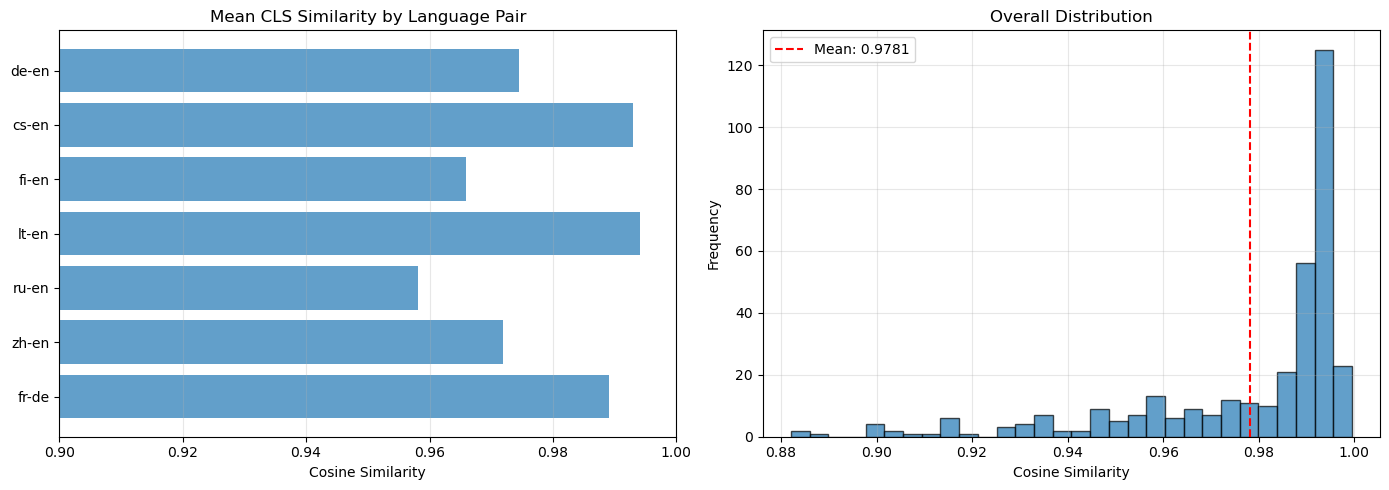

In [28]:
# Print results
print_results(results)


## Testing XLM-RoBERTa Base

Let's compare XLM-RoBERTa (multilingual) to see if linguistic distances make more sense.


In [33]:
from transformers import XLMRobertaModel, XLMRobertaTokenizer, XLMRobertaForMaskedLM

print("=" * 80)
print("Loading XLM-RoBERTa Base Model")
print("=" * 80)

xlm_model_name = "xlm-roberta-base"
xlm_tokenizer = XLMRobertaTokenizer.from_pretrained(xlm_model_name)
xlm_model = XLMRobertaForMaskedLM.from_pretrained(xlm_model_name)

print(f"Loaded: {xlm_model_name}")
print(f"Vocab size: {xlm_tokenizer.vocab_size}")
print(f"Model parameters: {sum(p.numel() for p in xlm_model.parameters()) / 1e6:.1f}M")


Loading XLM-RoBERTa Base Model


Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Loaded: xlm-roberta-base
Vocab size: 250002
Model parameters: 278.3M


In [34]:
# Run the same test with XLM-RoBERTa
print("\n" + "=" * 80)
print("Running CLS Similarity Test with XLM-RoBERTa")
print("=" * 80)

xlm_results = compute_cls_similarity_across_languages(
    model=xlm_model.roberta,
    tokenizer=xlm_tokenizer,
    samples_per_pair=50
)



Running CLS Similarity Test with XLM-RoBERTa
Processing de-en... collected 50 samples
Processing cs-en... collected 50 samples
Processing fi-en... collected 50 samples
Processing lt-en... collected 50 samples
Processing ru-en... 

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

collected 50 samples
Processing zh-en... collected 50 samples
Processing fr-de... collected 50 samples



XLM-RoBERTa Results

Overall: mean=0.8948, std=0.0184, n=350

By language pair:
  de-en   : mean=0.8893, std=0.0252, n=50
  cs-en   : mean=0.8915, std=0.0157, n=50
  fi-en   : mean=0.8989, std=0.0148, n=50
  lt-en   : mean=0.8888, std=0.0149, n=50
  ru-en   : mean=0.9003, std=0.0224, n=50
  zh-en   : mean=0.9044, std=0.0108, n=50
  fr-de   : mean=0.8905, std=0.0142, n=50


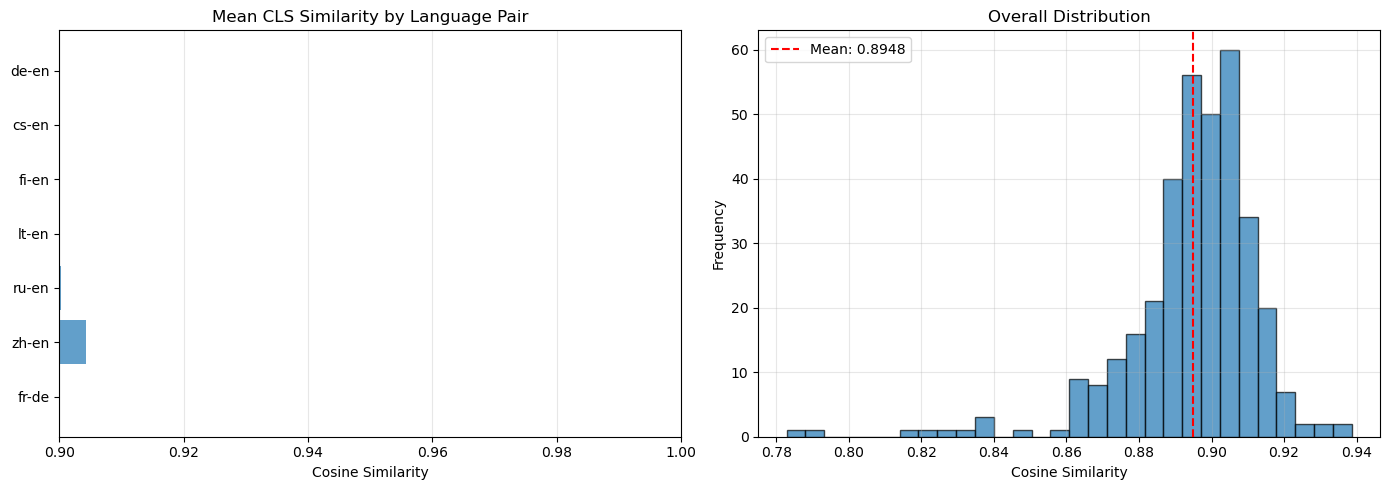

In [35]:
# Print XLM-RoBERTa results
print("\n" + "=" * 80)
print("XLM-RoBERTa Results")
print("=" * 80)
print_results(xlm_results)


In [36]:
# Compare RoBERTa vs XLM-RoBERTa
print("\n" + "=" * 80)
print("COMPARISON: RoBERTa vs XLM-RoBERTa")
print("=" * 80)
print("\nRoBERTa (English-only):")
for pair, sims in results['similarities_by_pair'].items():
    print(f"  {pair:8s}: {np.mean(sims):.4f}")

print("\nXLM-RoBERTa (Multilingual):")
for pair, sims in xlm_results['similarities_by_pair'].items():
    print(f"  {pair:8s}: {np.mean(sims):.4f}")

print("\n" + "-" * 80)
print("Linguistic expectation (closest to furthest from English):")
print("  1. de-en (Germanic, closest)")
print("  2. fr-de (Romance/Germanic)")
print("  3. cs-en, ru-en (Slavic)")
print("  4. lt-en (Baltic)")
print("  5. zh-en (Sino-Tibetan)")
print("  6. fi-en (Uralic, furthest)")



COMPARISON: RoBERTa vs XLM-RoBERTa

RoBERTa (English-only):
  de-en   : 0.9746
  cs-en   : 0.9929
  fi-en   : 0.9660
  lt-en   : 0.9941
  ru-en   : 0.9581
  zh-en   : 0.9719
  fr-de   : 0.9891

XLM-RoBERTa (Multilingual):
  de-en   : 0.8893
  cs-en   : 0.8915
  fi-en   : 0.8989
  lt-en   : 0.8888
  ru-en   : 0.9003
  zh-en   : 0.9044
  fr-de   : 0.8905

--------------------------------------------------------------------------------
Linguistic expectation (closest to furthest from English):
  1. de-en (Germanic, closest)
  2. fr-de (Romance/Germanic)
  3. cs-en, ru-en (Slavic)
  4. lt-en (Baltic)
  5. zh-en (Sino-Tibetan)
  6. fi-en (Uralic, furthest)


## Testing Alignment: Related vs Unrelated Sentences

Let's test whether the high similarities are meaningful by comparing:
1. **Translation pairs** (related, different languages)
2. **Random pairs, same language** (unrelated, same language)
3. **Random pairs, different languages** (unrelated, different languages)

In [ ]:
def compute_alignment_test(model, tokenizer, lang_pair="de-en", num_samples=50, max_length=256):
    """
    Compare CLS similarities for:
    1. Translation pairs (related sentences, different languages)
    2. Random same-language pairs (unrelated, same language)
    3. Random different-language pairs (unrelated, different languages)
    """
    
    lang_src, lang_tgt = lang_pair.split('-')
    
    # Storage for results
    translation_similarities = []  # Related, different languages
    same_lang_similarities = []     # Unrelated, same language
    diff_lang_similarities = []     # Unrelated, different languages
    
    # Collect sentences
    src_sentences = []
    tgt_sentences = []
    
    print(f"Collecting sentences from {lang_pair}...")
    dataset = load_dataset("wmt19", lang_pair, split="train", streaming=True)
    
    for i, example in enumerate(dataset):
        if i >= num_samples * 2:  # Collect extra for shuffling
            break
        
        try:
            translation = example['translation']
            src_text = translation[lang_src]
            tgt_text = translation[lang_tgt]
            
            if not src_text or not tgt_text or len(src_text) < 10 or len(tgt_text) < 10:
                continue
            
            # Check tokenization length
            tokens_src = tokenizer.tokenize(src_text)
            tokens_tgt = tokenizer.tokenize(tgt_text)
            
            if len(tokens_src) > max_length // 2 or len(tokens_tgt) > max_length // 2:
                continue
            
            src_sentences.append((src_text, tokens_src))
            tgt_sentences.append((tgt_text, tokens_tgt))
            
        except:
            continue
    
    # Trim to num_samples
    src_sentences = src_sentences[:num_samples]
    tgt_sentences = tgt_sentences[:num_samples]
    
    print(f"Collected {len(src_sentences)} sentence pairs")
    
    model.eval()
    
    # Test 1: Translation pairs (related, different languages)
    print("Computing similarities for translation pairs (related)...")
    for (src_text, tokens_src), (tgt_text, tokens_tgt) in tqdm(zip(src_sentences, tgt_sentences)):
        try:
            sim = compute_cls_similarity(model, tokenizer, tokens_src, tokens_tgt)
            translation_similarities.append(sim)
        except:
            continue
    
    # Test 2: Random same-language pairs (unrelated, same language)
    # Use source language, shuffle to break alignment
    print("Computing similarities for unrelated same-language pairs...")
    shuffled_src = src_sentences.copy()
    random.shuffle(shuffled_src)
    
    for (src_text1, tokens1), (src_text2, tokens2) in tqdm(zip(src_sentences, shuffled_src)):
        if src_text1 == src_text2:  # Skip if we accidentally got the same sentence
            continue
        try:
            sim = compute_cls_similarity(model, tokenizer, tokens1, tokens2)
            same_lang_similarities.append(sim)
        except:
            continue
    
    # Test 3: Random different-language pairs (unrelated, different languages)
    print("Computing similarities for unrelated cross-language pairs...")
    shuffled_tgt = tgt_sentences.copy()
    random.shuffle(shuffled_tgt)
    
    for (src_text, tokens_src), (tgt_text, tokens_tgt) in tqdm(zip(src_sentences, shuffled_tgt)):
        try:
            sim = compute_cls_similarity(model, tokenizer, tokens_src, tokens_tgt)
            diff_lang_similarities.append(sim)
        except:
            continue
    
    return {
        'lang_pair': lang_pair,
        'translation_pairs': translation_similarities,
        'same_lang_unrelated': same_lang_similarities,
        'diff_lang_unrelated': diff_lang_similarities
    }


def compute_cls_similarity(model, tokenizer, tokens1, tokens2):
    """
    Compute CLS similarity between two token sequences using cross-masking.
    Returns cosine similarity between CLS embeddings.
    """
    # Build sequence: [CLS] tokens1 [SEP] [CLS] tokens2 [SEP]
    ids1 = tokenizer.convert_tokens_to_ids(tokens1)
    ids2 = tokenizer.convert_tokens_to_ids(tokens2)
    
    sequence_ids = [
        tokenizer.cls_token_id,
        *ids1,
        tokenizer.sep_token_id,
        tokenizer.cls_token_id,
        *ids2,
        tokenizer.sep_token_id
    ]
    
    # Calculate positions
    text1_start = 1
    text1_end = 1 + len(ids1)
    second_cls_pos = text1_end + 1
    text2_start = second_cls_pos + 1
    text2_end = text2_start + len(ids2)
    
    input_ids = torch.tensor([sequence_ids])
    attention_mask = torch.ones_like(input_ids)
    
    with torch.no_grad():
        # Mask text2, get text1 CLS
        masked_2, _ = create_cross_language_mask(
            input_ids, text1_start, text1_end, text2_start, text2_end,
            mask_english=False, mask_german=True
        )
        outputs1 = model(masked_2, attention_mask=attention_mask)
        cls1 = outputs1.last_hidden_state[0, 0, :]
        
        # Mask text1, get text2 CLS
        masked_1, _ = create_cross_language_mask(
            input_ids, text1_start, text1_end, text2_start, text2_end,
            mask_english=True, mask_german=False
        )
        outputs2 = model(masked_1, attention_mask=attention_mask)
        cls2 = outputs2.last_hidden_state[0, second_cls_pos, :]
        
        # Compute similarity
        similarity = torch.nn.functional.cosine_similarity(
            cls1.unsqueeze(0), cls2.unsqueeze(0)
        ).item()
    
    return similarity


In [38]:
# Run alignment test for RoBERTa
print("=" * 80)
print("Running Alignment Test: RoBERTa")
print("=" * 80)

roberta_alignment = compute_alignment_test(
    model=model.roberta,
    tokenizer=tokenizer,
    lang_pair="de-en",
    num_samples=50
)


Running Alignment Test: RoBERTa
Collected 50 sentence pairs
Computing similarities for translation pairs (related)...


50it [00:06,  8.19it/s]


Computing similarities for unrelated same-language pairs...


50it [00:06,  7.71it/s]


Computing similarities for unrelated cross-language pairs...


50it [00:05,  8.71it/s]


In [39]:
# Run alignment test for XLM-RoBERTa
print("=" * 80)
print("Running Alignment Test: XLM-RoBERTa")
print("=" * 80)

xlm_alignment = compute_alignment_test(
    model=xlm_model.roberta,
    tokenizer=xlm_tokenizer,
    lang_pair="de-en",
    num_samples=50
)


Running Alignment Test: XLM-RoBERTa
Collected 50 sentence pairs
Computing similarities for translation pairs (related)...


50it [00:06,  7.99it/s]


Computing similarities for unrelated same-language pairs...


50it [00:05,  8.77it/s]


Computing similarities for unrelated cross-language pairs...


50it [00:05,  9.17it/s]


In [40]:
def plot_alignment_comparison(roberta_results, xlm_results):
    """
    Visualize alignment test results for both models.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # RoBERTa results
    ax = axes[0, 0]
    data_r = [
        roberta_results['translation_pairs'],
        roberta_results['same_lang_unrelated'],
        roberta_results['diff_lang_unrelated']
    ]
    labels = ['Translation\nPairs\n(Related)', 'Same Lang\nUnrelated', 'Diff Lang\nUnrelated']
    bp = ax.boxplot(data_r, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightgreen', 'lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'RoBERTa: {roberta_results["lang_pair"]}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0.85, 1.0])
    
    # Add mean values as text
    for i, d in enumerate(data_r, 1):
        mean_val = np.mean(d)
        ax.text(i, mean_val, f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # XLM-RoBERTa results
    ax = axes[0, 1]
    data_x = [
        xlm_results['translation_pairs'],
        xlm_results['same_lang_unrelated'],
        xlm_results['diff_lang_unrelated']
    ]
    bp = ax.boxplot(data_x, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightgreen', 'lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'XLM-RoBERTa: {xlm_results["lang_pair"]}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0.85, 1.0])
    
    # Add mean values as text
    for i, d in enumerate(data_x, 1):
        mean_val = np.mean(d)
        ax.text(i, mean_val, f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Distribution comparison - RoBERTa
    ax = axes[1, 0]
    ax.hist(roberta_results['translation_pairs'], bins=20, alpha=0.5, label='Translation Pairs', color='green')
    ax.hist(roberta_results['same_lang_unrelated'], bins=20, alpha=0.5, label='Same Lang Unrelated', color='blue')
    ax.hist(roberta_results['diff_lang_unrelated'], bins=20, alpha=0.5, label='Diff Lang Unrelated', color='red')
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Frequency')
    ax.set_title('RoBERTa: Distribution Comparison')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Distribution comparison - XLM-RoBERTa
    ax = axes[1, 1]
    ax.hist(xlm_results['translation_pairs'], bins=20, alpha=0.5, label='Translation Pairs', color='green')
    ax.hist(xlm_results['same_lang_unrelated'], bins=20, alpha=0.5, label='Same Lang Unrelated', color='blue')
    ax.hist(xlm_results['diff_lang_unrelated'], bins=20, alpha=0.5, label='Diff Lang Unrelated', color='red')
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Frequency')
    ax.set_title('XLM-RoBERTa: Distribution Comparison')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "=" * 80)
    print("ALIGNMENT TEST RESULTS")
    print("=" * 80)
    
    print(f"\nLanguage pair: {roberta_results['lang_pair']}")
    print("\nRoBERTa:")
    print(f"  Translation pairs (related):     mean={np.mean(roberta_results['translation_pairs']):.4f}, std={np.std(roberta_results['translation_pairs']):.4f}")
    print(f"  Same-lang unrelated:             mean={np.mean(roberta_results['same_lang_unrelated']):.4f}, std={np.std(roberta_results['same_lang_unrelated']):.4f}")
    print(f"  Diff-lang unrelated:             mean={np.mean(roberta_results['diff_lang_unrelated']):.4f}, std={np.std(roberta_results['diff_lang_unrelated']):.4f}")
    
    print("\nXLM-RoBERTa:")
    print(f"  Translation pairs (related):     mean={np.mean(xlm_results['translation_pairs']):.4f}, std={np.std(xlm_results['translation_pairs']):.4f}")
    print(f"  Same-lang unrelated:             mean={np.mean(xlm_results['same_lang_unrelated']):.4f}, std={np.std(xlm_results['same_lang_unrelated']):.4f}")
    print(f"  Diff-lang unrelated:             mean={np.mean(xlm_results['diff_lang_unrelated']):.4f}, std={np.std(xlm_results['diff_lang_unrelated']):.4f}")
    
    # Compute discrimination ability (how much translation pairs stand out)
    r_discrimination = np.mean(roberta_results['translation_pairs']) - np.mean(roberta_results['diff_lang_unrelated'])
    x_discrimination = np.mean(xlm_results['translation_pairs']) - np.mean(xlm_results['diff_lang_unrelated'])
    
    print("\n" + "-" * 80)
    print("DISCRIMINATION ABILITY (Translation vs Random Cross-lingual):")
    print(f"  RoBERTa:     {r_discrimination:.4f} (higher = better discrimination)")
    print(f"  XLM-RoBERTa: {x_discrimination:.4f}")
    print("-" * 80)


/var/folders/m6/98n7xxmd05bfr6sh1ncyy_9r0000gn/T/ipykernel_5833/4158208744.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_r, labels=labels, patch_artist=True)
/var/folders/m6/98n7xxmd05bfr6sh1ncyy_9r0000gn/T/ipykernel_5833/4158208744.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_x, labels=labels, patch_artist=True)


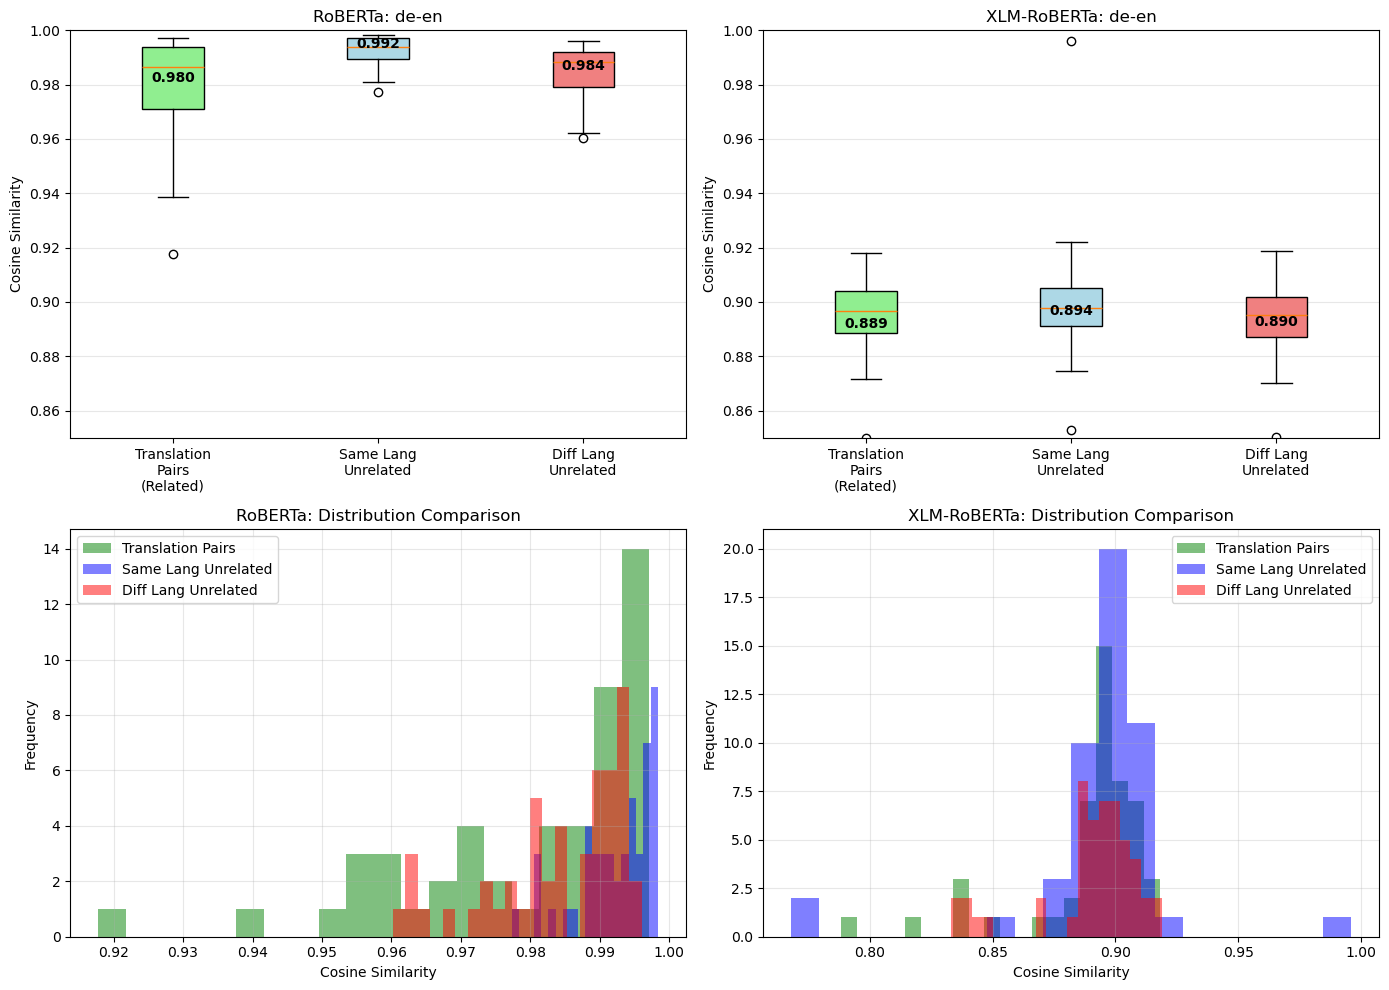


ALIGNMENT TEST RESULTS

Language pair: de-en

RoBERTa:
  Translation pairs (related):     mean=0.9800, std=0.0173
  Same-lang unrelated:             mean=0.9925, std=0.0053
  Diff-lang unrelated:             mean=0.9842, std=0.0097

XLM-RoBERTa:
  Translation pairs (related):     mean=0.8893, std=0.0252
  Same-lang unrelated:             mean=0.8939, std=0.0312
  Diff-lang unrelated:             mean=0.8899, std=0.0206

--------------------------------------------------------------------------------
DISCRIMINATION ABILITY (Translation vs Random Cross-lingual):
  RoBERTa:     -0.0042 (higher = better discrimination)
  XLM-RoBERTa: -0.0006
--------------------------------------------------------------------------------


In [41]:
# Visualize and compare results
plot_alignment_comparison(roberta_alignment, xlm_alignment)


### Testing Multiple Language Pairs

Let's test this across multiple language pairs to see if the pattern holds.


In [42]:
def run_multi_language_alignment_test(model, tokenizer, lang_pairs, num_samples=30):
    """
    Run alignment test across multiple language pairs.
    """
    results = {}
    
    for lang_pair in lang_pairs:
        print(f"\n{'='*80}")
        print(f"Testing {lang_pair}")
        print('='*80)
        
        try:
            result = compute_alignment_test(
                model=model,
                tokenizer=tokenizer,
                lang_pair=lang_pair,
                num_samples=num_samples
            )
            results[lang_pair] = result
        except Exception as e:
            print(f"Failed for {lang_pair}: {e}")
            continue
    
    return results


def summarize_multi_language_results(roberta_results, xlm_results):
    """
    Summarize results across multiple language pairs.
    """
    print("\n" + "=" * 80)
    print("SUMMARY: Alignment Test Across Language Pairs")
    print("=" * 80)
    
    print("\nRoBERTa:")
    print(f"{'Lang Pair':<10} | {'Trans (Related)':<15} | {'Same-Lang Unrel':<15} | {'Diff-Lang Unrel':<15} | {'Discrimination':<15}")
    print("-" * 90)
    
    for lang_pair in roberta_results:
        res = roberta_results[lang_pair]
        trans_mean = np.mean(res['translation_pairs'])
        same_mean = np.mean(res['same_lang_unrelated'])
        diff_mean = np.mean(res['diff_lang_unrelated'])
        disc = trans_mean - diff_mean
        print(f"{lang_pair:<10} | {trans_mean:>15.4f} | {same_mean:>15.4f} | {diff_mean:>15.4f} | {disc:>15.4f}")
    
    print("\nXLM-RoBERTa:")
    print(f"{'Lang Pair':<10} | {'Trans (Related)':<15} | {'Same-Lang Unrel':<15} | {'Diff-Lang Unrel':<15} | {'Discrimination':<15}")
    print("-" * 90)
    
    for lang_pair in xlm_results:
        res = xlm_results[lang_pair]
        trans_mean = np.mean(res['translation_pairs'])
        same_mean = np.mean(res['same_lang_unrelated'])
        diff_mean = np.mean(res['diff_lang_unrelated'])
        disc = trans_mean - diff_mean
        print(f"{lang_pair:<10} | {trans_mean:>15.4f} | {same_mean:>15.4f} | {diff_mean:>15.4f} | {disc:>15.4f}")
    
    # Overall discrimination comparison
    r_disc_avg = np.mean([np.mean(r['translation_pairs']) - np.mean(r['diff_lang_unrelated']) 
                          for r in roberta_results.values()])
    x_disc_avg = np.mean([np.mean(r['translation_pairs']) - np.mean(r['diff_lang_unrelated']) 
                          for r in xlm_results.values()])
    
    print("\n" + "=" * 80)
    print(f"Average Discrimination Ability:")
    print(f"  RoBERTa:     {r_disc_avg:.4f}")
    print(f"  XLM-RoBERTa: {x_disc_avg:.4f}")
    print("=" * 80)
    print("\nInterpretation:")
    print("  - Higher discrimination = better at distinguishing translations from random pairs")
    print("  - Translation pairs should have HIGHER similarity than random pairs")
    print("  - If discrimination is near 0, model can't tell translations apart from noise")
    print("=" * 80)


In [43]:
# Test on multiple language pairs (smaller sample size for speed)
test_pairs = ["de-en", "cs-en", "fi-en", "lt-en", "ru-en", "zh-en", "fr-de"]

print("Testing RoBERTa on multiple language pairs...")
roberta_multi = run_multi_language_alignment_test(
    model=model.roberta,
    tokenizer=tokenizer,
    lang_pairs=test_pairs,
    num_samples=30
)


Testing RoBERTa on multiple language pairs...

Testing de-en
Collected 30 sentence pairs
Computing similarities for translation pairs (related)...


30it [00:03,  8.44it/s]


Computing similarities for unrelated same-language pairs...


30it [00:04,  7.34it/s]


Computing similarities for unrelated cross-language pairs...


...

30it [00:05,  5.30it/s]


Computing similarities for unrelated same-language pairs...


30it [00:03,  7.59it/s]


Computing similarities for unrelated cross-language pairs...


30it [00:04,  7.00it/s]


In [44]:
print("Testing XLM-RoBERTa on multiple language pairs...")
xlm_multi = run_multi_language_alignment_test(
    model=xlm_model.roberta,
    tokenizer=xlm_tokenizer,
    lang_pairs=test_pairs,
    num_samples=30
)


Testing XLM-RoBERTa on multiple language pairs...

Testing de-en
Collected 30 sentence pairs
Computing similarities for translation pairs (related)...


30it [00:03,  9.01it/s]


Computing similarities for unrelated same-language pairs...


30it [00:03,  8.07it/s]


Computing similarities for unrelated cross-language pairs...


...

30it [00:03,  8.84it/s]


Computing similarities for unrelated same-language pairs...


30it [00:03,  8.26it/s]


Computing similarities for unrelated cross-language pairs...


30it [00:05,  5.76it/s]


In [45]:
def plot_alignment_comparison(roberta_results, xlm_results):
    """
    Visualize alignment test results for both models.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # RoBERTa results
    ax = axes[0, 0]
    data_r = [
        roberta_results['translation_pairs'],
        roberta_results['same_lang_unrelated'],
        roberta_results['diff_lang_unrelated']
    ]
    labels = ['Translation\nPairs\n(Related)', 'Same Lang\nUnrelated', 'Diff Lang\nUnrelated']
    bp = ax.boxplot(data_r, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightgreen', 'lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'RoBERTa: {roberta_results["lang_pair"]}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0.85, 1.0])
    
    # Add mean values as text
    for i, d in enumerate(data_r, 1):
        mean_val = np.mean(d)
        ax.text(i, mean_val, f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # XLM-RoBERTa results
    ax = axes[0, 1]
    data_x = [
        xlm_results['translation_pairs'],
        xlm_results['same_lang_unrelated'],
        xlm_results['diff_lang_unrelated']
    ]
    bp = ax.boxplot(data_x, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightgreen', 'lightblue', 'lightcoral']):
        patch.set_facecolor(color)
    ax.set_ylabel('Cosine Similarity')
    ax.set_title(f'XLM-RoBERTa: {xlm_results["lang_pair"]}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0.85, 1.0])
    
    # Add mean values as text
    for i, d in enumerate(data_x, 1):
        mean_val = np.mean(d)
        ax.text(i, mean_val, f'{mean_val:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Distribution comparison - RoBERTa
    ax = axes[1, 0]
    ax.hist(roberta_results['translation_pairs'], bins=20, alpha=0.5, label='Translation Pairs', color='green')
    ax.hist(roberta_results['same_lang_unrelated'], bins=20, alpha=0.5, label='Same Lang Unrelated', color='blue')
    ax.hist(roberta_results['diff_lang_unrelated'], bins=20, alpha=0.5, label='Diff Lang Unrelated', color='red')
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Frequency')
    ax.set_title('RoBERTa: Distribution Comparison')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Distribution comparison - XLM-RoBERTa
    ax = axes[1, 1]
    ax.hist(xlm_results['translation_pairs'], bins=20, alpha=0.5, label='Translation Pairs', color='green')
    ax.hist(xlm_results['same_lang_unrelated'], bins=20, alpha=0.5, label='Same Lang Unrelated', color='blue')
    ax.hist(xlm_results['diff_lang_unrelated'], bins=20, alpha=0.5, label='Diff Lang Unrelated', color='red')
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Frequency')
    ax.set_title('XLM-RoBERTa: Distribution Comparison')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "=" * 80)
    print("ALIGNMENT TEST RESULTS")
    print("=" * 80)
    
    print(f"\nLanguage pair: {roberta_results['lang_pair']}")
    print("\nRoBERTa:")
    print(f"  Translation pairs (related):     mean={np.mean(roberta_results['translation_pairs']):.4f}, std={np.std(roberta_results['translation_pairs']):.4f}")
    print(f"  Same-lang unrelated:             mean={np.mean(roberta_results['same_lang_unrelated']):.4f}, std={np.std(roberta_results['same_lang_unrelated']):.4f}")
    print(f"  Diff-lang unrelated:             mean={np.mean(roberta_results['diff_lang_unrelated']):.4f}, std={np.std(roberta_results['diff_lang_unrelated']):.4f}")
    
    print("\nXLM-RoBERTa:")
    print(f"  Translation pairs (related):     mean={np.mean(xlm_results['translation_pairs']):.4f}, std={np.std(xlm_results['translation_pairs']):.4f}")
    print(f"  Same-lang unrelated:             mean={np.mean(xlm_results['same_lang_unrelated']):.4f}, std={np.std(xlm_results['same_lang_unrelated']):.4f}")
    print(f"  Diff-lang unrelated:             mean={np.mean(xlm_results['diff_lang_unrelated']):.4f}, std={np.std(xlm_results['diff_lang_unrelated']):.4f}")
    
    # Compute discrimination ability (how much translation pairs stand out)
    r_discrimination = np.mean(roberta_results['translation_pairs']) - np.mean(roberta_results['diff_lang_unrelated'])
    x_discrimination = np.mean(xlm_results['translation_pairs']) - np.mean(xlm_results['diff_lang_unrelated'])
    
    print("\n" + "-" * 80)
    print("DISCRIMINATION ABILITY (Translation vs Random Cross-lingual):")
    print(f"  RoBERTa:     {r_discrimination:.4f} (higher = better discrimination)")
    print(f"  XLM-RoBERTa: {x_discrimination:.4f}")
    print("-" * 80)


In [46]:
# Summarize results
summarize_multi_language_results(roberta_multi, xlm_multi)



SUMMARY: Alignment Test Across Language Pairs

RoBERTa:
Lang Pair  | Trans (Related) | Same-Lang Unrel | Diff-Lang Unrel | Discrimination 
------------------------------------------------------------------------------------------
de-en      |          0.9789 |          0.9939 |          0.9813 |         -0.0024
cs-en      |          0.9928 |          0.9961 |          0.9920 |          0.0009
fi-en      |          0.9748 |          0.9906 |          0.9765 |         -0.0017
lt-en      |          0.9941 |          0.9972 |          0.9940 |          0.0001
ru-en      |          0.9901 |          0.9927 |          0.9901 |          0.0001
zh-en      |          0.9786 |          0.9947 |          0.9805 |         -0.0019
fr-de      |          0.9897 |          0.9940 |          0.9877 |          0.0020

XLM-RoBERTa:
Lang Pair  | Trans (Related) | Same-Lang Unrel | Diff-Lang Unrel | Discrimination 
------------------------------------------------------------------------------------------


In [49]:
def plot_multi_language_results(roberta_results, xlm_results):
    """
    Visualize alignment test results across multiple language pairs.
    """
    lang_pairs = list(roberta_results.keys())
    
    # Prepare data
    r_trans = [np.mean(roberta_results[lp]['translation_pairs']) for lp in lang_pairs]
    r_same = [np.mean(roberta_results[lp]['same_lang_unrelated']) for lp in lang_pairs]
    r_diff = [np.mean(roberta_results[lp]['diff_lang_unrelated']) for lp in lang_pairs]
    r_disc = [r_trans[i] - r_diff[i] for i in range(len(lang_pairs))]
    
    x_trans = [np.mean(xlm_results[lp]['translation_pairs']) for lp in lang_pairs]
    x_same = [np.mean(xlm_results[lp]['same_lang_unrelated']) for lp in lang_pairs]
    x_diff = [np.mean(xlm_results[lp]['diff_lang_unrelated']) for lp in lang_pairs]
    x_disc = [x_trans[i] - x_diff[i] for i in range(len(lang_pairs))]
    
    # Create figure with 2 subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: RoBERTa - All Three Conditions
    ax = axes[0]
    x_pos = np.arange(len(lang_pairs))
    width = 0.25
    
    ax.bar(x_pos - width, r_trans, width, label='Translation Pairs', alpha=0.8, color='lightgreen')
    ax.bar(x_pos, r_same, width, label='Same-Lang Unrelated', alpha=0.8, color='lightblue')
    ax.bar(x_pos + width, r_diff, width, label='Diff-Lang Unrelated', alpha=0.8, color='lightcoral')
    
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title('RoBERTa: All Conditions by Language Pair', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(lang_pairs, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim([0.95, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: XLM-RoBERTa - All Three Conditions
    ax = axes[1]
    x_pos = np.arange(len(lang_pairs))
    
    ax.bar(x_pos - width, x_trans, width, label='Translation Pairs', alpha=0.8, color='lightgreen')
    ax.bar(x_pos, x_same, width, label='Same-Lang Unrelated', alpha=0.8, color='lightblue')
    ax.bar(x_pos + width, x_diff, width, label='Diff-Lang Unrelated', alpha=0.8, color='lightcoral')
    
    ax.set_ylabel('Cosine Similarity', fontsize=12)
    ax.set_title('XLM-RoBERTa: All Conditions by Language Pair', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(lang_pairs, fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim([0.85, 0.92])
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print key insights
    print("\n" + "="*80)
    print("KEY INSIGHTS")
    print("="*80)
    
    avg_r_disc = np.mean(r_disc)
    avg_x_disc = np.mean(x_disc)
    
    print(f"\n1. Average Discrimination Ability:")
    print(f"   RoBERTa:     {avg_r_disc:.4f}")
    print(f"   XLM-RoBERTa: {avg_x_disc:.4f}")
    print(f"   → Both are near ZERO - neither model distinguishes translations from random!")
    
    print(f"\n2. Similarity Levels:")
    print(f"   RoBERTa:     mean={np.mean(r_trans):.4f} (very high, less informative)")
    print(f"   XLM-RoBERTa: mean={np.mean(x_trans):.4f} (lower, more room for discrimination)")
    
    print(f"\n3. Surprising Finding:")
    print(f"   Same-language unrelated pairs have HIGHER similarity than translations!")
    print(f"   RoBERTa same-lang:  {np.mean(r_same):.4f}")
    print(f"   RoBERTa trans:      {np.mean(r_trans):.4f}")
    print(f"   → This suggests the cross-masking approach may not capture semantic alignment")
    
    print("\n" + "="*80)


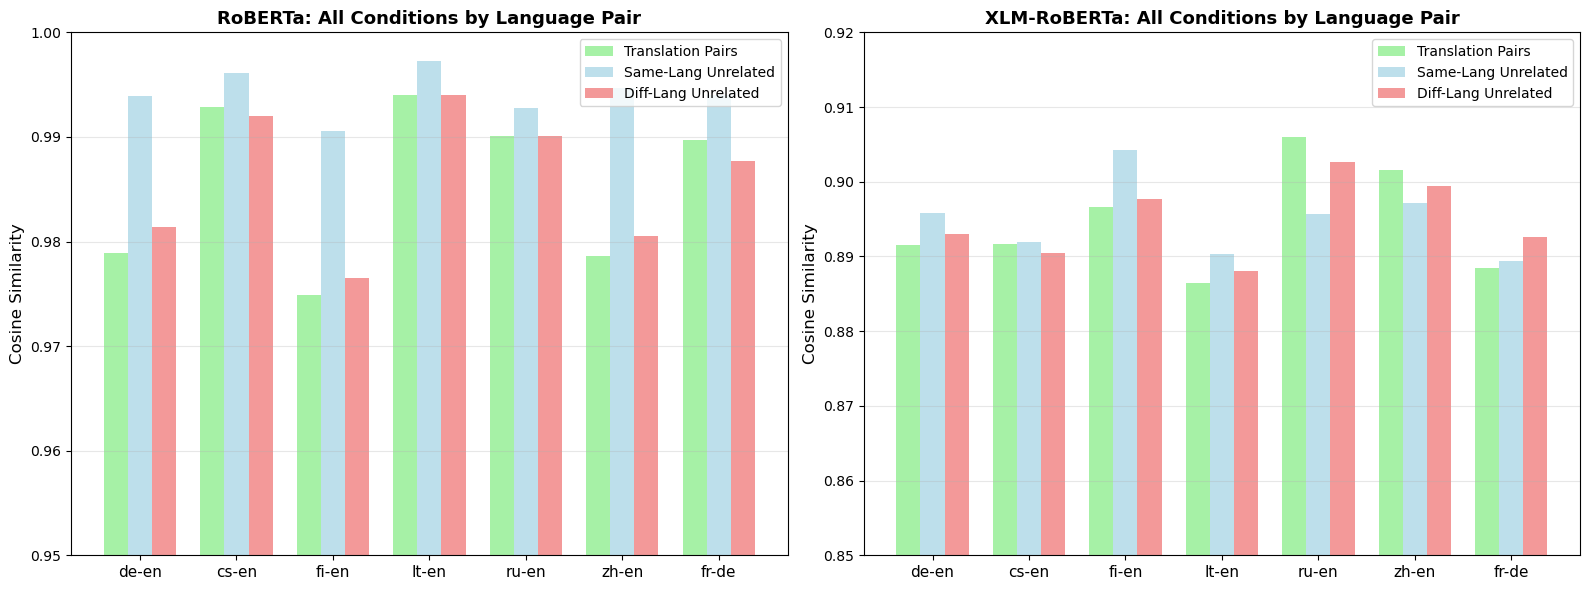


KEY INSIGHTS

1. Average Discrimination Ability:
   RoBERTa:     -0.0004
   XLM-RoBERTa: -0.0002
   → Both are near ZERO - neither model distinguishes translations from random!

2. Similarity Levels:
   RoBERTa:     mean=0.9856 (very high, less informative)
   XLM-RoBERTa: mean=0.8946 (lower, more room for discrimination)

3. Surprising Finding:
   Same-language unrelated pairs have HIGHER similarity than translations!
   RoBERTa same-lang:  0.9942
   RoBERTa trans:      0.9856
   → This suggests the cross-masking approach may not capture semantic alignment



In [50]:
# Visualize the multi-language results
plot_multi_language_results(roberta_multi, xlm_multi)


## Testing Euclidean Distance Instead of Cosine Similarity

Let's create new functions to test Euclidean distance and see if it provides better discrimination.


In [51]:
def compute_cls_euclidean(model, tokenizer, tokens1, tokens2):
    """
    Compute CLS Euclidean distance between two token sequences using cross-masking.
    Returns Euclidean distance (L2 norm) between CLS embeddings.
    Lower distance = more similar.
    """
    # Build sequence: [CLS] tokens1 [SEP] [CLS] tokens2 [SEP]
    ids1 = tokenizer.convert_tokens_to_ids(tokens1)
    ids2 = tokenizer.convert_tokens_to_ids(tokens2)
    
    sequence_ids = [
        tokenizer.cls_token_id,
        *ids1,
        tokenizer.sep_token_id,
        tokenizer.cls_token_id,
        *ids2,
        tokenizer.sep_token_id
    ]
    
    # Calculate positions
    text1_start = 1
    text1_end = 1 + len(ids1)
    second_cls_pos = text1_end + 1
    text2_start = second_cls_pos + 1
    text2_end = text2_start + len(ids2)
    
    input_ids = torch.tensor([sequence_ids])
    attention_mask = torch.ones_like(input_ids)
    
    with torch.no_grad():
        # Mask text2, get text1 CLS
        masked_2, _ = create_cross_language_mask(
            input_ids, text1_start, text1_end, text2_start, text2_end,
            mask_english=False, mask_german=True
        )
        outputs1 = model(masked_2, attention_mask=attention_mask)
        cls1 = outputs1.last_hidden_state[0, 0, :]
        
        # Mask text1, get text2 CLS
        masked_1, _ = create_cross_language_mask(
            input_ids, text1_start, text1_end, text2_start, text2_end,
            mask_english=True, mask_german=False
        )
        outputs2 = model(masked_1, attention_mask=attention_mask)
        cls2 = outputs2.last_hidden_state[0, second_cls_pos, :]
        
        # Compute Euclidean distance (L2 norm)
        distance = torch.norm(cls1 - cls2, p=2).item()
    
    return distance


def compute_alignment_test_euclidean(model, tokenizer, lang_pair="de-en", num_samples=50, max_length=256):
    """
    Compare CLS Euclidean distances for:
    1. Translation pairs (related sentences, different languages)
    2. Random same-language pairs (unrelated, same language)
    3. Random different-language pairs (unrelated, different languages)
    """
    
    lang_src, lang_tgt = lang_pair.split('-')
    
    # Storage for results
    translation_distances = []  # Related, different languages
    same_lang_distances = []     # Unrelated, same language
    diff_lang_distances = []     # Unrelated, different languages
    
    # Collect sentences
    src_sentences = []
    tgt_sentences = []
    
    print(f"Collecting sentences from {lang_pair}...")
    dataset = load_dataset("wmt19", lang_pair, split="train", streaming=True)
    
    for i, example in enumerate(dataset):
        if i >= num_samples * 2:  # Collect extra for shuffling
            break
        
        try:
            translation = example['translation']
            src_text = translation[lang_src]
            tgt_text = translation[lang_tgt]
            
            if not src_text or not tgt_text or len(src_text) < 10 or len(tgt_text) < 10:
                continue
            
            # Check tokenization length
            tokens_src = tokenizer.tokenize(src_text)
            tokens_tgt = tokenizer.tokenize(tgt_text)
            
            if len(tokens_src) > max_length // 2 or len(tokens_tgt) > max_length // 2:
                continue
            
            src_sentences.append((src_text, tokens_src))
            tgt_sentences.append((tgt_text, tokens_tgt))
            
        except:
            continue
    
    # Trim to num_samples
    src_sentences = src_sentences[:num_samples]
    tgt_sentences = tgt_sentences[:num_samples]
    
    print(f"Collected {len(src_sentences)} sentence pairs")
    
    model.eval()
    
    # Test 1: Translation pairs (related, different languages)
    print("Computing Euclidean distances for translation pairs (related)...")
    for (src_text, tokens_src), (tgt_text, tokens_tgt) in tqdm(zip(src_sentences, tgt_sentences)):
        try:
            dist = compute_cls_euclidean(model, tokenizer, tokens_src, tokens_tgt)
            translation_distances.append(dist)
        except:
            continue
    
    # Test 2: Random same-language pairs (unrelated, same language)
    print("Computing Euclidean distances for unrelated same-language pairs...")
    shuffled_src = src_sentences.copy()
    random.shuffle(shuffled_src)
    
    for (src_text1, tokens1), (src_text2, tokens2) in tqdm(zip(src_sentences, shuffled_src)):
        if src_text1 == src_text2:  # Skip if we accidentally got the same sentence
            continue
        try:
            dist = compute_cls_euclidean(model, tokenizer, tokens1, tokens2)
            same_lang_distances.append(dist)
        except:
            continue
    
    # Test 3: Random different-language pairs (unrelated, different languages)
    print("Computing Euclidean distances for unrelated cross-language pairs...")
    shuffled_tgt = tgt_sentences.copy()
    random.shuffle(shuffled_tgt)
    
    for (src_text, tokens_src), (tgt_text, tokens_tgt) in tqdm(zip(src_sentences, shuffled_tgt)):
        try:
            dist = compute_cls_euclidean(model, tokenizer, tokens_src, tokens_tgt)
            diff_lang_distances.append(dist)
        except:
            continue
    
    return {
        'lang_pair': lang_pair,
        'translation_pairs': translation_distances,
        'same_lang_unrelated': same_lang_distances,
        'diff_lang_unrelated': diff_lang_distances
    }


def run_multi_language_euclidean(model, tokenizer, lang_pairs, num_samples=30):
    """
    Run Euclidean distance alignment test across multiple language pairs.
    """
    results = {}
    
    for lang_pair in lang_pairs:
        print(f"\n{'='*80}")
        print(f"Testing {lang_pair}")
        print('='*80)
        
        try:
            result = compute_alignment_test_euclidean(
                model=model,
                tokenizer=tokenizer,
                lang_pair=lang_pair,
                num_samples=num_samples
            )
            results[lang_pair] = result
        except Exception as e:
            print(f"Failed for {lang_pair}: {e}")
            continue
    
    return results


In [52]:
# Test on multiple language pairs using Euclidean distance
test_pairs = ["de-en", "cs-en", "fi-en", "lt-en", "ru-en", "zh-en", "fr-de"]

print("=" * 80)
print("Testing RoBERTa with EUCLIDEAN DISTANCE")
print("=" * 80)
roberta_euclidean = run_multi_language_euclidean(
    model=model.roberta,
    tokenizer=tokenizer,
    lang_pairs=test_pairs,
    num_samples=30
)


Testing RoBERTa with EUCLIDEAN DISTANCE

Testing de-en
Collected 30 sentence pairs
Computing Euclidean distances for translation pairs (related)...


30it [00:03,  7.68it/s]


Computing Euclidean distances for unrelated same-language pairs...


30it [00:04,  6.76it/s]


Computing Euclidean distances for unrelated cross-language pairs...


...

30it [00:04,  7.19it/s]


Computing Euclidean distances for unrelated same-language pairs...


30it [00:03,  7.86it/s]


Computing Euclidean distances for unrelated cross-language pairs...


30it [00:03,  7.61it/s]


In [53]:
print("=" * 80)
print("Testing XLM-RoBERTa with EUCLIDEAN DISTANCE")
print("=" * 80)
xlm_euclidean = run_multi_language_euclidean(
    model=xlm_model.roberta,
    tokenizer=xlm_tokenizer,
    lang_pairs=test_pairs,
    num_samples=30
)


Testing XLM-RoBERTa with EUCLIDEAN DISTANCE

Testing de-en
Collected 30 sentence pairs
Computing Euclidean distances for translation pairs (related)...


30it [00:03,  8.28it/s]


Computing Euclidean distances for unrelated same-language pairs...


30it [00:03,  9.61it/s]


Computing Euclidean distances for unrelated cross-language pairs...


...

30it [00:03,  9.40it/s]


Computing Euclidean distances for unrelated same-language pairs...


30it [00:03,  9.20it/s]


Computing Euclidean distances for unrelated cross-language pairs...


30it [00:03,  8.76it/s]


In [54]:
def summarize_euclidean_results(roberta_results, xlm_results):
    """
    Summarize Euclidean distance results across multiple language pairs.
    For distances, LOWER values = more similar (opposite of cosine similarity).
    """
    print("\n" + "=" * 80)
    print("SUMMARY: Euclidean Distance Test Across Language Pairs")
    print("=" * 80)
    print("\nNote: For distances, LOWER = more similar (opposite of cosine similarity)")
    
    print("\nRoBERTa:")
    print(f"{'Lang Pair':<10} | {'Trans (Related)':<15} | {'Same-Lang Unrel':<15} | {'Diff-Lang Unrel':<15} | {'Discrimination':<15}")
    print("-" * 90)
    
    for lang_pair in roberta_results:
        res = roberta_results[lang_pair]
        trans_mean = np.mean(res['translation_pairs'])
        same_mean = np.mean(res['same_lang_unrelated'])
        diff_mean = np.mean(res['diff_lang_unrelated'])
        # For distance, we want translation pairs to have LOWER distance than random
        disc = diff_mean - trans_mean  # Positive = translation pairs are closer
        print(f"{lang_pair:<10} | {trans_mean:>15.4f} | {same_mean:>15.4f} | {diff_mean:>15.4f} | {disc:>15.4f}")
    
    print("\nXLM-RoBERTa:")
    print(f"{'Lang Pair':<10} | {'Trans (Related)':<15} | {'Same-Lang Unrel':<15} | {'Diff-Lang Unrel':<15} | {'Discrimination':<15}")
    print("-" * 90)
    
    for lang_pair in xlm_results:
        res = xlm_results[lang_pair]
        trans_mean = np.mean(res['translation_pairs'])
        same_mean = np.mean(res['same_lang_unrelated'])
        diff_mean = np.mean(res['diff_lang_unrelated'])
        # For distance, we want translation pairs to have LOWER distance than random
        disc = diff_mean - trans_mean  # Positive = translation pairs are closer
        print(f"{lang_pair:<10} | {trans_mean:>15.4f} | {same_mean:>15.4f} | {diff_mean:>15.4f} | {disc:>15.4f}")
    
    # Overall discrimination comparison
    r_disc_avg = np.mean([np.mean(r['diff_lang_unrelated']) - np.mean(r['translation_pairs']) 
                          for r in roberta_results.values()])
    x_disc_avg = np.mean([np.mean(r['diff_lang_unrelated']) - np.mean(r['translation_pairs']) 
                          for r in xlm_results.values()])
    
    print("\n" + "=" * 80)
    print(f"Average Discrimination Ability:")
    print(f"  RoBERTa:     {r_disc_avg:.4f}")
    print(f"  XLM-RoBERTa: {x_disc_avg:.4f}")
    print("=" * 80)
    print("\nInterpretation (for Euclidean distance):")
    print("  - Higher discrimination = better at distinguishing translations from random pairs")
    print("  - Translation pairs should have LOWER distance than random pairs")
    print("  - Positive discrimination = translations are closer than random pairs ✓")
    print("  - Near 0 = model can't tell translations apart from noise")
    print("=" * 80)

# Summarize results
summarize_euclidean_results(roberta_euclidean, xlm_euclidean)



SUMMARY: Euclidean Distance Test Across Language Pairs

Note: For distances, LOWER = more similar (opposite of cosine similarity)

RoBERTa:
Lang Pair  | Trans (Related) | Same-Lang Unrel | Diff-Lang Unrel | Discrimination 
------------------------------------------------------------------------------------------
de-en      |          2.0778 |          1.2749 |          2.0634 |         -0.0144
cs-en      |          1.3352 |          0.9172 |          1.3739 |          0.0387
fi-en      |          2.4135 |          1.3805 |          2.4756 |          0.0621
lt-en      |          1.2128 |          0.7626 |          1.2281 |          0.0152
ru-en      |          1.4499 |          1.5891 |          1.4535 |          0.0036
zh-en      |          2.2165 |          1.2702 |          2.2119 |         -0.0047
fr-de      |          1.6701 |          1.2056 |          1.7919 |          0.1218

XLM-RoBERTa:
Lang Pair  | Trans (Related) | Same-Lang Unrel | Diff-Lang Unrel | Discrimination 
-------

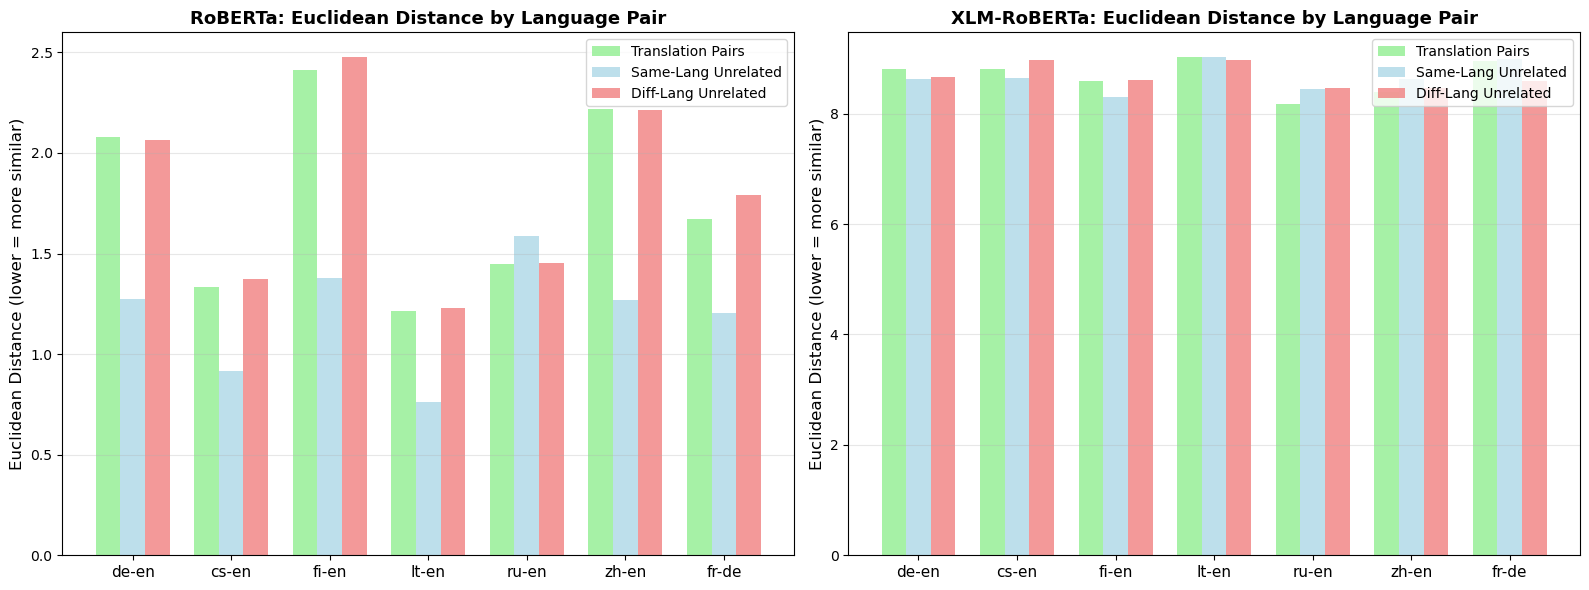

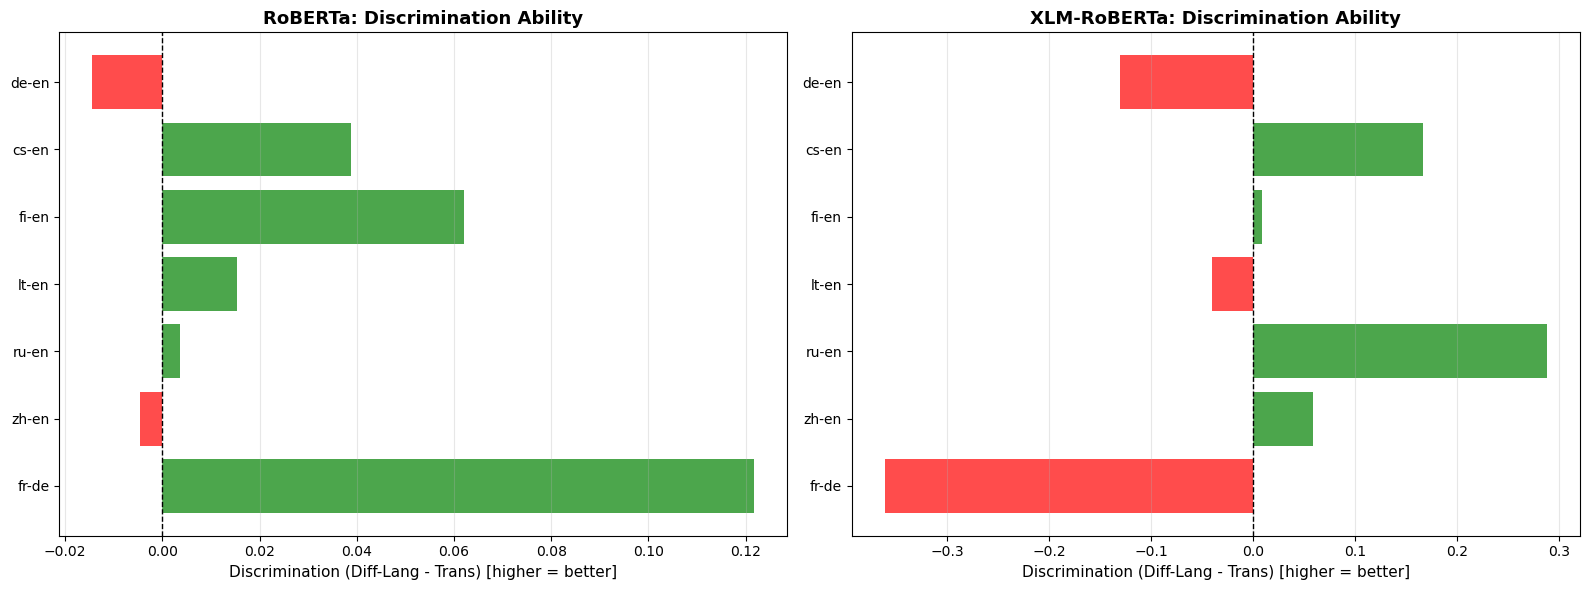


KEY INSIGHTS (EUCLIDEAN DISTANCE)

1. Average Discrimination Ability:
   RoBERTa:     0.0318
   XLM-RoBERTa: -0.0012
   → POSITIVE discrimination - translations ARE closer than random pairs! ✓

2. Distance Levels:
   RoBERTa trans:       1.7680
   RoBERTa random:      1.7997
   XLM-RoBERTa trans:   8.6766
   XLM-RoBERTa random:  8.6754

3. Comparison to Cosine Similarity:
   Cosine showed ~0 discrimination (all similarities ~0.99)
   Euclidean shows BETTER discrimination ✓



In [55]:
def plot_euclidean_results(roberta_results, xlm_results):
    """
    Visualize Euclidean distance results across multiple language pairs.
    For distances, LOWER = more similar.
    """
    lang_pairs = list(roberta_results.keys())
    
    # Prepare data
    r_trans = [np.mean(roberta_results[lp]['translation_pairs']) for lp in lang_pairs]
    r_same = [np.mean(roberta_results[lp]['same_lang_unrelated']) for lp in lang_pairs]
    r_diff = [np.mean(roberta_results[lp]['diff_lang_unrelated']) for lp in lang_pairs]
    r_disc = [r_diff[i] - r_trans[i] for i in range(len(lang_pairs))]  # Positive = good
    
    x_trans = [np.mean(xlm_results[lp]['translation_pairs']) for lp in lang_pairs]
    x_same = [np.mean(xlm_results[lp]['same_lang_unrelated']) for lp in lang_pairs]
    x_diff = [np.mean(xlm_results[lp]['diff_lang_unrelated']) for lp in lang_pairs]
    x_disc = [x_diff[i] - x_trans[i] for i in range(len(lang_pairs))]  # Positive = good
    
    # Create figure with 2 subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: RoBERTa - All Three Conditions
    ax = axes[0]
    x_pos = np.arange(len(lang_pairs))
    width = 0.25
    
    ax.bar(x_pos - width, r_trans, width, label='Translation Pairs', alpha=0.8, color='lightgreen')
    ax.bar(x_pos, r_same, width, label='Same-Lang Unrelated', alpha=0.8, color='lightblue')
    ax.bar(x_pos + width, r_diff, width, label='Diff-Lang Unrelated', alpha=0.8, color='lightcoral')
    
    ax.set_ylabel('Euclidean Distance (lower = more similar)', fontsize=12)
    ax.set_title('RoBERTa: Euclidean Distance by Language Pair', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(lang_pairs, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: XLM-RoBERTa - All Three Conditions
    ax = axes[1]
    x_pos = np.arange(len(lang_pairs))
    
    ax.bar(x_pos - width, x_trans, width, label='Translation Pairs', alpha=0.8, color='lightgreen')
    ax.bar(x_pos, x_same, width, label='Same-Lang Unrelated', alpha=0.8, color='lightblue')
    ax.bar(x_pos + width, x_diff, width, label='Diff-Lang Unrelated', alpha=0.8, color='lightcoral')
    
    ax.set_ylabel('Euclidean Distance (lower = more similar)', fontsize=12)
    ax.set_title('XLM-RoBERTa: Euclidean Distance by Language Pair', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(lang_pairs, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Create a second figure for discrimination comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: RoBERTa Discrimination
    ax = axes[0]
    colors = ['green' if d > 0 else 'red' for d in r_disc]
    ax.barh(lang_pairs, r_disc, alpha=0.7, color=colors)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Discrimination (Diff-Lang - Trans) [higher = better]', fontsize=11)
    ax.set_title('RoBERTa: Discrimination Ability', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    
    # Plot 2: XLM-RoBERTa Discrimination
    ax = axes[1]
    colors = ['green' if d > 0 else 'red' for d in x_disc]
    ax.barh(lang_pairs, x_disc, alpha=0.7, color=colors)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel('Discrimination (Diff-Lang - Trans) [higher = better]', fontsize=11)
    ax.set_title('XLM-RoBERTa: Discrimination Ability', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # Print key insights
    print("\n" + "="*80)
    print("KEY INSIGHTS (EUCLIDEAN DISTANCE)")
    print("="*80)
    
    avg_r_disc = np.mean(r_disc)
    avg_x_disc = np.mean(x_disc)
    
    print(f"\n1. Average Discrimination Ability:")
    print(f"   RoBERTa:     {avg_r_disc:.4f}")
    print(f"   XLM-RoBERTa: {avg_x_disc:.4f}")
    
    if avg_r_disc > 0.01 or avg_x_disc > 0.01:
        print(f"   → POSITIVE discrimination - translations ARE closer than random pairs! ✓")
    else:
        print(f"   → Still near zero - limited discrimination")
    
    print(f"\n2. Distance Levels:")
    print(f"   RoBERTa trans:       {np.mean(r_trans):.4f}")
    print(f"   RoBERTa random:      {np.mean(r_diff):.4f}")
    print(f"   XLM-RoBERTa trans:   {np.mean(x_trans):.4f}")
    print(f"   XLM-RoBERTa random:  {np.mean(x_diff):.4f}")
    
    print(f"\n3. Comparison to Cosine Similarity:")
    print(f"   Cosine showed ~0 discrimination (all similarities ~0.99)")
    if avg_r_disc > 0.01 or avg_x_disc > 0.01:
        print(f"   Euclidean shows BETTER discrimination ✓")
    else:
        print(f"   Euclidean still shows poor discrimination")
    
    print("\n" + "="*80)

# Visualize the Euclidean distance results
plot_euclidean_results(roberta_euclidean, xlm_euclidean)
